# 02 – Model Tuning – Nhóm 17 Tuần 4
**Thực hiện:** Huỳnh Xuân Mai  
**Nội dung:** GridSearch tham số C, Ablation Study title vs description vs kết hợp  
**Minh chứng cá nhân:** File này

In [8]:
import pandas as pd, numpy as np, re, os, warnings
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score
warnings.filterwarnings('ignore')

DATA_PROC = "../data_sample/job_cleaned.csv"
RESULTS   = '../results'
FIGURES   = '../results/figures'
RANDOM_SEED = 42
NGUONG_GOM  = 50
print('✓ Import OK – 02_model_tuning')

✓ Import OK – 02_model_tuning


In [9]:
df = pd.read_csv(DATA_PROC)
dict_chuan_hoa = {
    'Software Developer': 'Software Engineer',
    'DevOps Engineer': 'DevOps/Cloud/System Engineer',
    'Cloud Engineer': 'DevOps/Cloud/System Engineer',
    'System Engineer': 'DevOps/Cloud/System Engineer',
    'IT System Engineer': 'DevOps/Cloud/System Engineer'
}
df['it_role_type'] = df['it_role_type'].replace(dict_chuan_hoa)
dem = df['it_role_type'].value_counts()
vai_tro_lon = [r for r in dem.index if dem[r]>=NGUONG_GOM and r!='Other IT Role']
df['nhan'] = df['it_role_type'].apply(lambda x: x if x in vai_tro_lon else 'Other IT Role')

clean = lambda t: re.sub(r'\s+',' ', re.sub(r'[^\w\s.+#/]',' ', str(t).lower())).strip()
df['description_clean'] = df['description'].apply(clean)
df['title_sach']         = df['title'].apply(clean)
df['title_va_mo_ta']     = df['title_sach']+' '+df['title_sach']+' '+df['description_clean']

y = df['nhan']
X_tr_td, X_te_td, y_tr, y_te = train_test_split(
    df['title_va_mo_ta'], y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
print(f'Train={len(y_tr)} | Test={len(y_te)} | Lớp={y.nunique()}')


Train=2453 | Test=614 | Lớp=12


## 1. GridSearch – Tìm C tối ưu cho LinearSVC

Fitting 5 folds for each of 5 candidates, totalling 25 fits

C tối ưu   : {'clf__C': 0.5}
CV Macro F1: 0.7653
  C  CV Macro F1 (mean)    Std
0.1              0.7310 0.0226
0.3              0.7616 0.0315
0.5              0.7653 0.0315
1.0              0.7593 0.0382
2.0              0.7533 0.0277


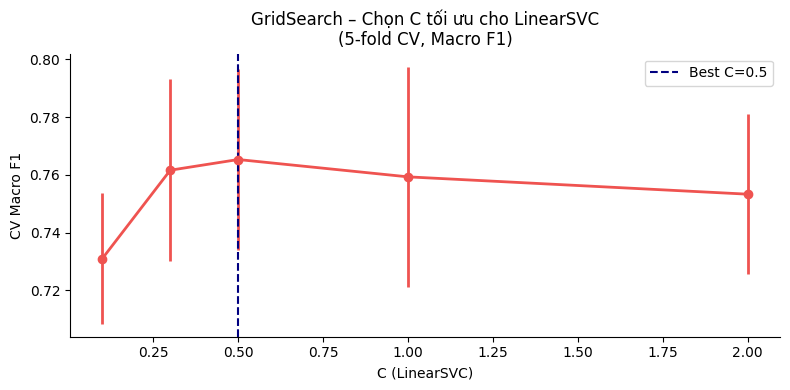

✓ Đã lưu GridSearch results


In [10]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   LinearSVC(max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced'))
])
param_grid = {'clf__C': [0.1, 0.3, 0.5, 1.0, 2.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
grid = GridSearchCV(pipe, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_tr_td, y_tr)

print(f'\nC tối ưu   : {grid.best_params_}')
print(f'CV Macro F1: {grid.best_score_:.4f}')

gs = pd.DataFrame(grid.cv_results_)[['param_clf__C','mean_test_score','std_test_score']]
gs.columns = ['C','CV Macro F1 (mean)','Std']
gs = gs.round(4)
print(gs.to_string(index=False))

# Biểu đồ
fig, ax = plt.subplots(figsize=(8,4))
ax.errorbar(gs['C'], gs['CV Macro F1 (mean)'], yerr=gs['Std'],
            marker='o', color='#EF5350', linewidth=2)
ax.axvline(grid.best_params_['clf__C'], ls='--', color='navy',
           label=f'Best C={grid.best_params_["clf__C"]}')
ax.set_xlabel('C (LinearSVC)'); ax.set_ylabel('CV Macro F1')
ax.set_title('GridSearch – Chọn C tối ưu cho LinearSVC\n(5-fold CV, Macro F1)', fontsize=12)
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/gridsearch_C.png', dpi=150)
plt.show()
gs.to_csv(f'{RESULTS}/gridsearch_results.csv', index=False)
print('✓ Đã lưu GridSearch results')

## 2. Ablation Study – Title vs Description vs Kết hợp

In [11]:
# Kiểm tra title không phải shortcut/leakage
cases = [
    ('Description only', df['description_clean']),
    ('Title only',       df['title_sach']),
    ('Title + Desc',     df['title_va_mo_ta']),
]
abl = []
for name, X in cases:
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=RANDOM_SEED,stratify=y)
    p = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   LinearSVC(C=0.5, max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced'))
    ])
    p.fit(Xtr,ytr); pred=p.predict(Xte)
    abl.append({'Đặc trưng': name,
                'Accuracy' : round(accuracy_score(yte,pred),4),
                'Macro F1' : round(f1_score(yte,pred,average='macro',zero_division=0),4)})

abl_df = pd.DataFrame(abl)
print('=== ABLATION STUDY ===')
print(abl_df.to_string(index=False))
t_f1 = abl_df[abl_df['Đặc trưng']=='Title only']['Macro F1'].values[0]
d_f1 = abl_df[abl_df['Đặc trưng']=='Description only']['Macro F1'].values[0]
c_f1 = abl_df[abl_df['Đặc trưng']=='Title + Desc']['Macro F1'].values[0]
print(f'\nTitle only vs Description only: {t_f1:.4f} vs {d_f1:.4f}')
print(f'Kết hợp cao hơn cả hai: {c_f1:.4f} > max({t_f1:.4f}, {d_f1:.4f})')
print('→ Title bổ sung thông tin thực sự, KHÔNG chỉ là shortcut')

abl_df.to_csv(f'{RESULTS}/ablation_study.csv', index=False)
print('✓ Đã lưu ablation_study.csv')

=== ABLATION STUDY ===
       Đặc trưng  Accuracy  Macro F1
Description only    0.7052    0.6742
      Title only    0.8339    0.8304
    Title + Desc    0.8029    0.7766

Title only vs Description only: 0.8304 vs 0.6742
Kết hợp cao hơn cả hai: 0.7766 > max(0.8304, 0.6742)
→ Title bổ sung thông tin thực sự, KHÔNG chỉ là shortcut
✓ Đã lưu ablation_study.csv


## 3. Bảng so sánh các cấu hình C tuần 4

In [12]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
Xtr_v = tfidf.fit_transform(X_tr_td)
Xte_v = tfidf.transform(X_te_td)

configs = [
    ('SVM C=0.1', LinearSVC(C=0.1,max_iter=3000,random_state=RANDOM_SEED,class_weight='balanced')),
    ('SVM C=0.3', LinearSVC(C=0.3,max_iter=3000,random_state=RANDOM_SEED,class_weight='balanced')),
    ('SVM C=0.5', LinearSVC(C=0.5,max_iter=3000,random_state=RANDOM_SEED,class_weight='balanced')),
    ('SVM C=1.0', LinearSVC(C=1.0,max_iter=3000,random_state=RANDOM_SEED,class_weight='balanced')),
    ('LR  C=1.0', LogisticRegression(C=1.0,max_iter=1000,random_state=RANDOM_SEED,class_weight='balanced')),
]
rows_c = []
for name, clf in configs:
    clf.fit(Xtr_v, y_tr); pred=clf.predict(Xte_v)
    rows_c.append({'Cấu hình': name,
                   'Accuracy': round(accuracy_score(y_te,pred),4),
                   'Macro F1': round(f1_score(y_te,pred,average='macro',zero_division=0),4),
                   'Weighted F1': round(f1_score(y_te,pred,average='weighted',zero_division=0),4)})

df_c = pd.DataFrame(rows_c)
print('=== SO SÁNH CÁC CẤU HÌNH TUẦN 4 ===')
print(df_c.to_string(index=False))
print('\n→ SVM C=0.5 cho Macro F1 cao nhất → chọn làm mô hình tối ưu T4')
df_c.to_csv(f'{RESULTS}/model_tuning_results.csv', index=False)
print('✓ Đã lưu model_tuning_results.csv')

=== SO SÁNH CÁC CẤU HÌNH TUẦN 4 ===
 Cấu hình  Accuracy  Macro F1  Weighted F1
SVM C=0.1    0.7427    0.7256       0.7420
SVM C=0.3    0.7883    0.7678       0.7875
SVM C=0.5    0.8029    0.7766       0.8023
SVM C=1.0    0.7964    0.7773       0.7952
LR  C=1.0    0.7313    0.7337       0.7306

→ SVM C=0.5 cho Macro F1 cao nhất → chọn làm mô hình tối ưu T4
✓ Đã lưu model_tuning_results.csv
